<div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 40px; margin-top: 0;">
    <div style="flex: 0 0 auto; margin-left: 0; margin-bottom: 0; margin-top: 0;">
        <img src="./pics/UCSD Logo.png" alt="UCSD Logo" style="width: 179px; margin-bottom: 0px; margin-top: 20px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/sdsc-logo.png" alt="SDSC Logo" style="width: 300px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/usda-logo.png" alt="USGS Logo" style="width: 100px; margin-bottom: 0px;">
    </div>
    <div style="flex: 0 0 auto; margin-left: auto; margin-bottom: 0; margin-top: 20px;">
        <img src="./pics/wstc-logo.png" alt="WSTC Logo" style="width: 100px; height: 100px; margin-bottom: 0px;">
    </div>
</div>

<h1 style="text-align: center; font-size: 48px; margin-top: 0;">National Agriculture Imagery Program (NAIP)</h1>

In this notebook, we will explore a data product from the [National Agriculture Imagery Program (NAIP)](https://naip-usdaonline.hub.arcgis.com/).

## What is NAIP? 

According to the main site NAIP site hosted by the US Department of Agriculture: 

*The NAIP imagery program acquires aerial imagery during the agricultural growing seasons in the United States.  A primary goal of the NAIP program is to make digital ortho photography available to governmental agencies and the public within a year of acquisition.*

*NAIP is administered through the USDA's Farm Production and Conservation Business Center (FPAC-BC) Geospatial Enterprise Operations (GEO) Branch.  This "leaf-on" imagery is used as a base layer for GIS programs in the Farm Service Agency's County Service Centers, and is used to maintain the Common Land Unit (CLU) boundaries.*

In this notebook, we will access NAIP data via the [GeoAI python package](https://opengeoai.org/). 

### Importing Libraries

In [2]:
!pip install geoai-py --quiet
print("✓ geoai installé")

  DEPRECATION: Building 'antlr4-python3-runtime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'antlr4-python3-runtime'. Discussion can be found at https://github.com/pypa/pip/issues/6334
ERROR: Could not install packages due to an OSError: [Errno 13] Permission denied: '/opt/conda/etc/jupyter/jupyter_notebook_config.d/jupyter-server-proxy.json'
Consider using the `--user` option or check the permissions.

✓ geoai installé


In [4]:
!pip install geoai-py leafmap --quiet
print("✓ installé")

✓ installé


In [5]:
from geoai.download import (
    download_naip,
    download_overture_buildings,
    extract_building_stats,
)
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import rasterio
from pyproj import Transformer
from shapely.geometry import box
import rasterio.windows
from rasterio.windows import Window
from rasterio.transform import xy

We will start by defining a bounding box to download a tiff file for exploration. For exploration purposes, we've decided to define a 1km by 1km bounding box within Independence Lake, California. Note that it is possible that we download more than one TIFF file, since there could be more than one file that intersects with our bounding box.

In [6]:
# Bounding Box in World Geodetic System 1984 (WGS84)
bbox_wgs84 = (-120.2935365, 39.4475718, -120.2835365, 39.4555718)

In [7]:
# Download NAIP imagery for the specified region
downloaded_files = download_naip(
    bbox=bbox_wgs84,
    output_dir="naip_data",
    max_items=2
)

print(f"Downloaded {len(downloaded_files)} files.")

m_3912038_ne_10_060_20220720.tif: 100%|██████████| 449M/449M [01:07<00:00, 7.00MiB/s]   
m_3912038_ne_10_060_20200716.tif: 100%|██████████| 459M/459M [01:10<00:00, 6.85MiB/s]   

Downloaded 2 files.


Success! We were able to download a couple of files that intersect our bounding box. As we mentioned previously, we ended up downloading more than 1 file. Since the purpose of this notebook is exploration, we will proceed to delete one of the files. 

In [8]:
to_delete = Path("./naip_data/m_3912038_ne_10_060_20200716.tif")

if to_delete.exists():
    to_delete.unlink()
    print(f"Deleted: {to_delete}")
else:
    print(f"File not found (nothing deleted): {to_delete}")

Deleted: naip_data/m_3912038_ne_10_060_20200716.tif


### Metadata and sanity check

Now that we have a file to work with, we will proceed to do a quick sanity check of the file we kept.

In [9]:
naip_path = "./naip_data/m_3912038_ne_10_060_20220720.tif"

with rasterio.open(naip_path) as src:
    print("File:", naip_path)
    print("CRS:", src.crs)
    print("Size (WxH):", src.width, "x", src.height)
    print("Count (bands):", src.count)
    print("Dtypes:", src.dtypes)
    print("Nodata:", src.nodata)
    print("Bounds:", src.bounds)
    print("Transform:\n", src.transform)
    print("Res (pixel size):", src.res)

File: ./naip_data/m_3912038_ne_10_060_20220720.tif
CRS: EPSG:26910
Size (WxH): 9980 x 12500
Count (bands): 4
Dtypes: ('uint8', 'uint8', 'uint8', 'uint8')
Nodata: None
Bounds: BoundingBox(left=730884.0, bottom=4368576.0, right=736872.0, top=4376076.0)
Transform:
 | 0.60, 0.00, 730884.00|
| 0.00,-0.60, 4376076.00|
| 0.00, 0.00, 1.00|
Res (pixel size): (0.6, 0.6)


What can we observe from this metadata? Let's dissagregate:

- The file uses ESPG:26910
- The total size is 9980x12500 pixels, where each pixel is at a 0.6m resolution.
- It has a total of 4 bands, Red, Green, Blue, and Near Infrared (NIR)

### Visualization 

After our quick sanity check and review of the data, let's do a quick visualization.

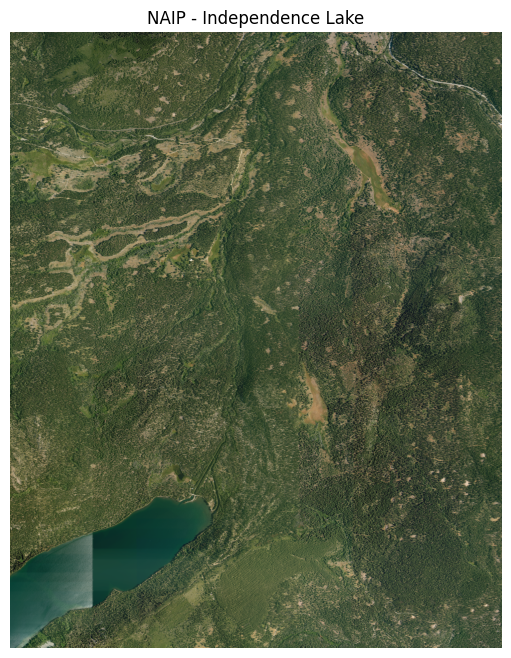

In [10]:
with rasterio.open(naip_path) as src:
    # Keeping 1/8th sample for demo purposes
    scale = 8  
    preview = src.read(
        indexes=[1,2,3], 
        out_shape=(3, src.height // scale, src.width // scale),
        resampling=rasterio.enums.Resampling.bilinear
    ).astype(np.float32)

rgb = np.transpose(preview, (1,2,0))

plt.figure(figsize=(10,8))
plt.imshow(np.clip(rgb / (np.nanmax(rgb) + 1e-12), 0, 1))
plt.title("NAIP - Independence Lake")
plt.axis("off")
plt.show()

### Array representation

Now that we have visualized our image, let's proceed to see an array representation of it. 

In [11]:
with rasterio.open(naip_path) as src:
    arr_chw = src.read() 
    
arr_hwc = np.transpose(arr_chw, (1, 2, 0))
for b in range(arr_chw.shape[0]):
    band = arr_chw[b].astype(np.float32)
    nodata = src.nodata
    if nodata is not None:
        band[band == nodata] = np.nan
    print(f"Band {b+1}: min={np.nanmin(band):.3f}, max={np.nanmax(band):.3f}, mean={np.nanmean(band):.3f}")

Band 1: min=1.000, max=206.000, mean=59.655
Band 2: min=1.000, max=205.000, mean=68.386
Band 3: min=3.000, max=204.000, mean=46.562
Band 4: min=1.000, max=202.000, mean=97.874


In [12]:
# Display the array
arr_hwc

array([[[ 86,  77,  55, 110],
        [ 91,  80,  58, 114],
        [ 80,  78,  48, 129],
        ...,
        [ 31,  46,  32,  68],
        [ 55,  65,  43, 104],
        [ 57,  66,  43, 115]],

       [[ 40,  51,  31,  90],
        [ 48,  59,  34, 115],
        [ 59,  69,  38, 134],
        ...,
        [ 27,  44,  32,  57],
        [ 36,  50,  37,  53],
        [ 36,  48,  36,  49]],

       [[ 22,  41,  24,  81],
        [ 26,  46,  26,  95],
        [ 39,  57,  32, 119],
        ...,
        [ 32,  47,  36,  55],
        [ 42,  53,  38,  51],
        [ 38,  49,  37,  44]],

       ...,

       [[ 21,  62,  56,   1],
        [ 45,  74,  69,   1],
        [ 86,  98,  91,  10],
        ...,
        [ 47,  57,  44,  61],
        [ 27,  45,  33,  49],
        [ 47,  56,  41,  62]],

       [[ 36,  69,  65,   1],
        [ 86, 103,  99,   8],
        [ 94, 108, 103,  15],
        ...,
        [ 20,  36,  30,  34],
        [ 28,  43,  34,  41],
        [ 56,  60,  48,  62]],

       [[ 62

Proceed to the tasks notebook and complete the tasks associated to this module.